In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from prophet import Prophet

df=pd.read_csv('../data/merged_data.csv')

print("Shape:", df.shape)
print("Data loaded:!")


Shape: (940, 22)
Data loaded:!


In [6]:
prophet_df=df.groupby('ActivityDate')['TotalSteps'].mean().reset_index()
prophet_df.columns = ['ds','y']

print("Prophet data shape:", prophet_df.shape)
prophet_df.head()


Prophet data shape: (31, 2)


,ds,y
0,2016-04-12,8236.848485
1,2016-04-13,7198.727273
2,2016-04-14,7743.575758
3,2016-04-15,7533.848485
4,2016-04-16,8679.156250


In [7]:
model = Prophet()
model.fit(prophet_df)

print("Model trained successfully!")

12:06:42 - cmdstanpy - INFO - Chain [1] start processing
12:06:43 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [8]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print("Forecast shape:", forecast.shape)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

Forecast shape: (61, 16)


,ds,yhat,yhat_lower,yhat_upper
51,2016-06-02,6116.457268,5150.413032,7196.874981
52,2016-06-03,6301.563009,5260.732707,7297.756981
53,2016-06-04,6984.123986,6010.050277,8011.289974
54,2016-06-05,5790.301016,4818.719912,6768.011476
55,2016-06-06,6635.281642,5645.231001,7719.021093
56,2016-06-07,6874.879717,5915.519479,7831.175670
57,2016-06-08,6293.708506,5305.998066,7309.570904
58,2016-06-09,5907.891256,4887.317810,6902.657234
59,2016-06-10,6092.996997,5096.704486,7124.229071
60,2016-06-11,6775.557974,5800.326857,7796.919681


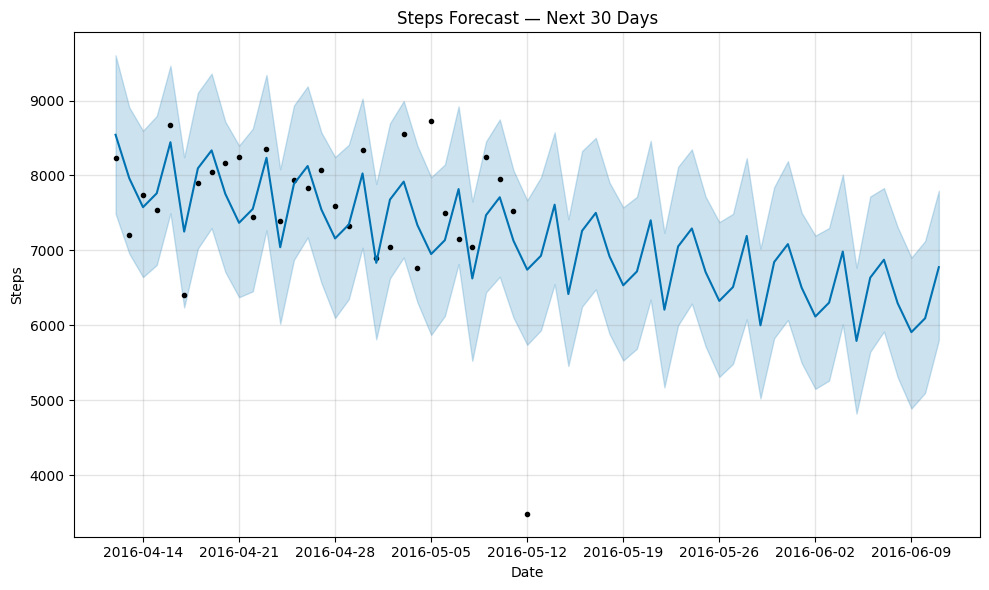

In [9]:
model.plot(forecast)
plt.title('Steps Forecast — Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.tight_layout()
plt.show()

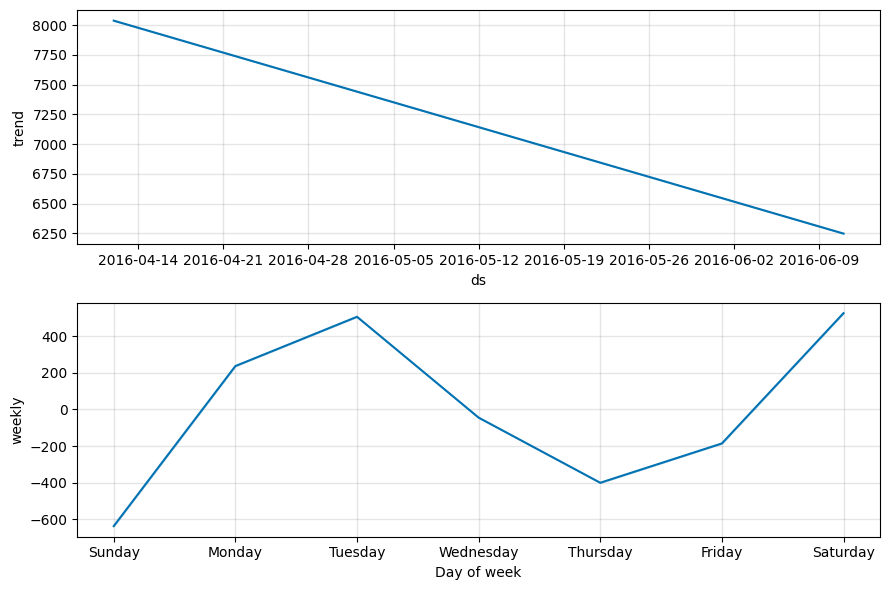

In [10]:
model.plot_components(forecast)
plt.tight_layout()
plt.show()